<a href="https://colab.research.google.com/github/theoaangelis/tarefasacademicas/blob/main/buscaOrdenacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial Interativo: Invariantes de Laço e Complexidade de Algoritmos

**Nome:** Theo Araujo de Angelis  
**Matrícula:** 202100022980  
**Duração:** 150 minutos (2h30min)  
**Formato:** Laboratório prático com entregável avaliativo

## Objetivos de Aprendizagem
Ao final desta aula, você será capaz de:
1. ✓ Compreender e aplicar o conceito de **invariantes de laço** para provar corretude
2. ✓ Implementar e analisar algoritmos de busca (linear e binária) e ordenação (insertion, selection, bubble)
3. ✓ Comparar complexidades assintóticas através de experimentos práticos
4. ✓ Escolher o algoritmo adequado baseado nas características da entrada

## Cronograma (revisado para garantir tempo do entregável)

| Parte | Conteúdo | Tempo |
|-------|----------|-------|
| **1** | Busca Binária e Invariantes | **25 min** |
| **2** | Ordenação: Insertion, Selection, Bubble | **40 min** |
| **3** | Experimento de Complexidade (demo guiada) | **20 min** |
| **4** | 🎯 **Entregável — Exercícios Avaliativos** | **55 min** |
| — | Encerramento e dúvidas | 10 min |

> ⚠️ **Importante:** as Partes 1–3 são expositivas e **devem caber em 85 min**. Execute as células à medida que o professor avança; **não pare para otimizar código nessas partes** — as otimizações viram exercícios da Parte 4.

---

## Conceito Fundamental: Invariantes de Loop

Uma **invariante de laço** é uma propriedade que permanece verdadeira durante toda a execução de um loop. Para provar corretude, verificamos três fases:

1. **Inicialização:** é verdadeira antes da primeira iteração.
2. **Manutenção:** se verdadeira no início da iteração, permanece verdadeira no final.
3. **Terminação:** quando o loop termina, a invariante garante que o algoritmo atingiu seu objetivo.

**Analogia:** pense na invariante como uma *promessa* que o algoritmo mantém em cada passo. Se conseguimos provar que a promessa é mantida do início ao fim, temos certeza de que o algoritmo funciona.


---
## PARTE 1: Busca Binária e a Divisão do Espaço de Busca  ⏱️ 25 min

### 1.1 Motivação

Imagine procurar um nome específico em uma lista telefônica com 1 milhão de nomes:

- **Busca Linear:** verificar nome por nome — $\Theta(n)$ — até 1.000.000 de comparações.
- **Busca Binária:** abrir no meio e decidir em qual metade procurar — $\Theta(\log n)$ — apenas ~20 comparações.

**Pré-requisito crucial:** a busca binária **só funciona em arrays ordenados**.

### 1.2 A Invariante da Busca Binária

**Invariante:** se o valor alvo $v$ existe no array $A$, então ele **obrigatoriamente** está no intervalo $A[low..high]$.

- **Inicialização:** $low=0$ e $high=n-1$ — o intervalo contém todo o array.
- **Manutenção:** a cada iteração, ajustamos $low$ ou $high$ baseado em $A[mid]$, mantendo $v$ no intervalo.
- **Terminação:** quando $low > high$, o intervalo está vazio e sabemos que $v$ não está no array.

### 1.3 Implementação com Visualização da Invariante


In [ ]:
def busca_binaria(A, v):
    low = 0
    high = len(A) - 1
    iteracao = 1

    print(f"Buscando v={v} no array {A}")
    print("-" * 40)

    while low <= high:
        mid = (low + high) // 2

        # Comprovando a invariante visualmente:
        print(f"Iteração {iteracao} | Intervalo A[{low}..{high}]: {A[low:high+1]}")
        print(f"Avaliando A[{mid}] = {A[mid]}")

        if A[mid] == v:
            print(f"=> Encontrado no índice {mid}!\n")
            return mid
        elif A[mid] < v:
            low = mid + 1
            print(f"=> Alvo é maior. Ajustando low para {low}\n")
        else:
            high = mid - 1
            print(f"=> Alvo é menor. Ajustando high para {high}\n")

        iteracao += 1

    print("=> Retorna NIL (não encontrado)\n")
    return None

# Teste com o traço da aula
A = [2, 5, 8, 12, 16, 23, 38, 56, 72, 91]
busca_binaria(A, 23)


Buscando v=23 no array [2, 5, 8, 12, 16, 23, 38, 56, 72, 91]
----------------------------------------
Iteração 1 | Intervalo A[0..9]: [2, 5, 8, 12, 16, 23, 38, 56, 72, 91]
Avaliando A[4] = 16
=> Alvo é maior. Ajustando low para 5

Iteração 2 | Intervalo A[5..9]: [23, 38, 56, 72, 91]
Avaliando A[7] = 56
=> Alvo é menor. Ajustando high para 6

Iteração 3 | Intervalo A[5..6]: [23, 38]
Avaliando A[5] = 23
=> Encontrado no índice 5!



5

### ✏️ Verificação rápida (2 min — discussão oral, não escrita)

1. Quantas iterações foram necessárias para encontrar o valor 23?
2. Quantas iterações seriam necessárias para confirmar que 50 **não** está no array? (rode se quiser: `busca_binaria(A, 50)`)
3. Qual é o pior caso para um array de tamanho 10?

> Não gaste mais de 2 min aqui. A implementação formal de busca vai ser cobrada no **Exercício 1** da Parte 4.


---
## PARTE 2: Algoritmos de Ordenação  ⏱️ 40 min

### 2.1 Insertion Sort: ordenando como cartas de baralho

O Insertion Sort funciona como organizar cartas na mão:
- A mão **esquerda** contém as cartas já ordenadas.
- Pegamos a próxima carta com a mão **direita**.
- Inserimos essa carta no lugar correto na mão esquerda.

**Características:** in-place ($O(1)$ de espaço), estável, adaptativo (rápido em arrays quase ordenados).

### 2.2 A Invariante do Insertion Sort

No início de cada iteração $j$, o subarray $A[0..j-1]$ contém os mesmos elementos que estavam originalmente nessas posições, porém **em ordem crescente**.

### 2.3 Complexidade

| Caso | Complexidade | Exemplo |
|------|-------------|---------|
| Melhor | $\Theta(n)$ | `[1,2,3,4,5]` |
| Médio | $\Theta(n^2)$ | Array aleatório |
| Pior | $\Theta(n^2)$ | `[5,4,3,2,1]` |

### 2.4 Implementação com Visualização da Invariante


In [ ]:
def insertion_sort(A):
    arr = A.copy()  # não altera o original
    n = len(arr)

    for j in range(1, n):
        key = arr[j]
        i = j - 1

        # A invariante diz que arr[0..j-1] está ordenado:
        print(f"Início j={j} | Ordenado: {arr[0:j]} | Inserindo key={key}")

        while i >= 0 and arr[i] > key:
            arr[i + 1] = arr[i]
            i -= 1
        arr[i + 1] = key

        print(f"Fim    j={j} | Estado:   {arr}\n")

    return arr

insertion_sort([5, 2, 4, 6, 1, 3])


Início j=1 | Ordenado: [5] | Inserindo key=2
Fim    j=1 | Estado:   [2, 5, 4, 6, 1, 3]

Início j=2 | Ordenado: [2, 5] | Inserindo key=4
Fim    j=2 | Estado:   [2, 4, 5, 6, 1, 3]

Início j=3 | Ordenado: [2, 4, 5] | Inserindo key=6
Fim    j=3 | Estado:   [2, 4, 5, 6, 1, 3]

Início j=4 | Ordenado: [2, 4, 5, 6] | Inserindo key=1
Fim    j=4 | Estado:   [1, 2, 4, 5, 6, 3]

Início j=5 | Ordenado: [1, 2, 4, 5, 6] | Inserindo key=3
Fim    j=5 | Estado:   [1, 2, 3, 4, 5, 6]



[1, 2, 3, 4, 5, 6]

### 2.5 Selection Sort vs Bubble Sort: estratégias opostas

Ambos são $\Theta(n^2)$ no caso médio e pior, mas com mecânicas **completamente opostas**:

**Selection Sort — "encontre o mínimo":**
- A cada passo, encontra o menor elemento não ordenado e o coloca em sua posição final.
- Invariante: $A[0..i-1]$ contém os $i$ menores elementos, já ordenados e em posições finais.
- Faz apenas $O(n)$ **trocas** — ótimo quando escrita na memória é cara (Flash, EEPROM).
- Sempre $\Theta(n^2)$, mesmo em array ordenado.

**Bubble Sort — "borbulhe os maiores":**
- Compara pares adjacentes e empurra os maiores para o final.
- Invariante: após a iteração $i$, os $i$ maiores elementos já estão no final, ordenados.
- Com flag de troca, detecta array ordenado: melhor caso $\Theta(n)$.
- Faz muitas trocas — ruim se escrita é cara.

### 2.6 Implementação e Comparação


In [ ]:
def selection_sort(A):
    arr = A.copy()
    n = len(arr)
    trocas = 0

    for i in range(n - 1):
        min_idx = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j

        if min_idx != i:
            arr[i], arr[min_idx] = arr[min_idx], arr[i]
            trocas += 1

        print(f"Iter {i+1} | Invariante A[0..{i}]: {arr[0:i+1]} | Array: {arr}")

    print(f"Total de trocas Selection Sort: {trocas}")
    return arr

def bubble_sort_otimizado(A):
    arr = A.copy()
    n = len(arr)

    for i in range(n - 1):
        trocou = False
        for j in range(n - 1 - i):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                trocou = True

        print(f"Passagem {i+1} | Maiores fixados: {arr[n-1-i:]} | Array: {arr}")

        if not trocou:
            print("Nenhuma troca — array ordenado precocemente!")
            break

    return arr

print("=== SELECTION SORT ===")
selection_sort([4, 1, 3, 9, 7])

print("\n=== BUBBLE SORT OTIMIZADO ===")
bubble_sort_otimizado([5, 1, 4, 2, 8])


=== SELECTION SORT ===
Iter 1 | Invariante A[0..0]: [1] | Array: [1, 4, 3, 9, 7]
Iter 2 | Invariante A[0..1]: [1, 3] | Array: [1, 3, 4, 9, 7]
Iter 3 | Invariante A[0..2]: [1, 3, 4] | Array: [1, 3, 4, 9, 7]
Iter 4 | Invariante A[0..3]: [1, 3, 4, 7] | Array: [1, 3, 4, 7, 9]
Total de trocas Selection Sort: 3

=== BUBBLE SORT OTIMIZADO ===
Passagem 1 | Maiores fixados: [8] | Array: [1, 4, 2, 5, 8]
Passagem 2 | Maiores fixados: [5, 8] | Array: [1, 2, 4, 5, 8]
Passagem 3 | Maiores fixados: [4, 5, 8] | Array: [1, 2, 4, 5, 8]
Nenhuma troca — array ordenado precocemente!


[1, 2, 4, 5, 8]

### ✏️ Verificação rápida (2 min — discussão oral)

1. Rode `bubble_sort_otimizado([1, 2, 3, 4, 5])` — quantas passagens foram necessárias?
2. Por que o Selection Sort **não pode** usar a mesma otimização de parada antecipada?

> Essa discussão vira o **Exercício 2** (análise de invariantes) na Parte 4.


---
## PARTE 3: Experimento de Complexidade Assintótica  ⏱️ 20 min

### 3.1 Da teoria à prática

Na teoria:
- **Insertion Sort:** $\Theta(n)$ no melhor, $\Theta(n^2)$ no pior.
- **Selection Sort:** $\Theta(n^2)$ sempre.

Vamos **medir e visualizar** com arrays reais. Tamanhos: 100, 500, 1000, 2000, 4000.

> 💡 **Fluxo:** rode a célula abaixo e observe o gráfico. **Não altere o código agora** — interpretação do gráfico vira pergunta do entregável.


Executando simulações de tempo. Aguarde...



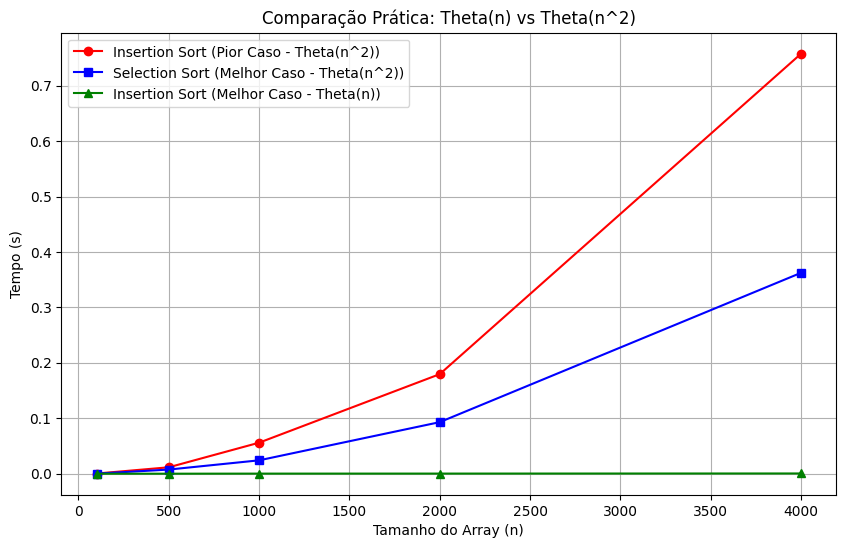

In [ ]:
import time
import matplotlib.pyplot as plt

def insertion_clean(arr):
    for j in range(1, len(arr)):
        key = arr[j]
        i = j - 1
        while i >= 0 and arr[i] > key:
            arr[i + 1] = arr[i]
            i -= 1
        arr[i + 1] = key

def selection_clean(arr):
    n = len(arr)
    for i in range(n - 1):
        min_idx = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]

tamanhos = [100, 500, 1000, 2000, 4000]
t_ins_pior, t_ins_melhor, t_sel_melhor = [], [], []

print("Executando simulações de tempo. Aguarde...\n")

for n in tamanhos:
    arr_pior    = list(range(n, 0, -1))  # ordem decrescente
    arr_melhor  = list(range(n))         # já ordenado

    copia = arr_pior.copy();   t0 = time.time(); insertion_clean(copia); t_ins_pior.append(time.time()-t0)
    copia = arr_melhor.copy(); t0 = time.time(); insertion_clean(copia); t_ins_melhor.append(time.time()-t0)
    copia = arr_melhor.copy(); t0 = time.time(); selection_clean(copia); t_sel_melhor.append(time.time()-t0)

plt.figure(figsize=(10, 6))
plt.plot(tamanhos, t_ins_pior,   'r-o', label='Insertion Sort (Pior Caso - Theta(n^2))')
plt.plot(tamanhos, t_sel_melhor, 'b-s', label='Selection Sort (Melhor Caso - Theta(n^2))')
plt.plot(tamanhos, t_ins_melhor, 'g-^', label='Insertion Sort (Melhor Caso - Theta(n))')
plt.title('Comparação Prática: Theta(n) vs Theta(n^2)')
plt.xlabel('Tamanho do Array (n)')
plt.ylabel('Tempo (s)')
plt.legend(); plt.grid(True); plt.show()


### 3.2 Análise dos Resultados (discussão de 5 min)

1. **Linha verde (Insertion — melhor caso):** crescimento linear, quase reta → confirma $\Theta(n)$.
2. **Linhas vermelha e azul:** crescimento quadrático — ao dobrar $n$, o tempo **quadruplica**.
3. **Selection Sort** é ligeiramente mais rápido que **Insertion (pior caso)** por fazer menos trocas.

**Conclusão:** algoritmos $O(n^2)$ só são aceitáveis para arrays pequenos (< 1000). Para volumes maiores → Merge/Quick Sort ($O(n \log n)$).

> ⏰ **Ponto de controle:** se chegamos aqui com ≤ 85 min decorridos, seguimos para o entregável com folga.


---
# 🎯 PARTE 4: ENTREGÁVEL — Atividade Avaliativa  ⏱️ 55 min

## 📋 Instruções de Submissão

- **Formato:** este próprio notebook com suas respostas e implementações.
- **Nome na primeira célula** (capa) — não esqueça.
- **Prazo:** ao final da aula, submeta no SIGAA o link do seu Colab compartilhado.

### Sugestão de alocação de tempo

| Exercício | Pontos | Tempo sugerido |
|-----------|--------|----------------|
| Ex. 1 — Busca linear | 2,0 | 8 min |
| Ex. 2 — Análise de invariantes | 3,0 | 15 min |
| Ex. 3 — Busca híbrida | 3,0 | 20 min |
| Ex. 4 — Tomada de decisão | 2,0 | 10 min |
| Revisão e salvamento | — | 2 min |


---
### 📝 Exercício 1: Implementação de Busca Linear (2,0 pontos) — ~8 min

A busca binária é eficiente ($\Theta(\log n)$), mas requer array ordenado. Quando o array **não** está ordenado, usamos **busca linear** ($\Theta(n)$).

**Tarefa:** implemente `busca_linear(A, v)` que:
- Procura `v` em `A` (não ordenado).
- Retorna o índice se encontrado, ou `None` caso contrário.
- Imprime cada passo (similar à busca binária).

**Teste com:** `A = [23, 5, 91, 12, 8, 2, 56, 38, 16, 72]`
- `busca_linear(A, 38)` → índice 7
- `busca_linear(A, 100)` → `None`


In [1]:
# EXERCÍCIO 1: Sua implementação aqui
def busca_linear(A, v):
    """Busca linear em array não ordenado. Retorna o índice ou None."""
    n = len(A)
    print(f"Buscando v={v} em A={A}")
    print(f"{'Passo':<6} {'Índice':<8} {'A[i]':<8} {'Comparação'}")
    print("-" * 40)

    for i in range(n):
        print(f"{i+1:<6} {i:<8} {A[i]:<8} {A[i]} == {v} → {'Encontrado' if A[i] == v else 'X'}")
        if A[i] == v:
            print(f"\nResultado: índice {i} | Comparações: {i+1}")
            return i

    print(f"\nResultado: None | Comparações: {n} (elemento não encontrado)")
    return None

# Testes
A = [23, 5, 91, 12, 8, 2, 56, 38, 16, 72]
print("Teste 1:"); resultado1 = busca_linear(A, 38)
print("\nTeste 2:"); resultado2 = busca_linear(A, 100)

# Suas respostas:
# 1. Comparações para encontrar 38: 8
# 2. Comparações para confirmar que 100 não existe: 10
# 3. Pior caso da busca linear: O(n), se o elemento está na última posição ou não está no array


Teste 1:
Buscando v=38 em A=[23, 5, 91, 12, 8, 2, 56, 38, 16, 72]
Passo  Índice   A[i]     Comparação
----------------------------------------
1      0        23       23 == 38 → X
2      1        5        5 == 38 → X
3      2        91       91 == 38 → X
4      3        12       12 == 38 → X
5      4        8        8 == 38 → X
6      5        2        2 == 38 → X
7      6        56       56 == 38 → X
8      7        38       38 == 38 → Encontrado

Resultado: índice 7 | Comparações: 8

Teste 2:
Buscando v=100 em A=[23, 5, 91, 12, 8, 2, 56, 38, 16, 72]
Passo  Índice   A[i]     Comparação
----------------------------------------
1      0        23       23 == 100 → X
2      1        5        5 == 100 → X
3      2        91       91 == 100 → X
4      3        12       12 == 100 → X
5      4        8        8 == 100 → X
6      5        2        2 == 100 → X
7      6        56       56 == 100 → X
8      7        38       38 == 100 → X
9      8        16       16 == 100 → X
10     9        

---
### 📝 Exercício 2: Análise de Invariantes (3,0 pontos) — ~15 min

Considere o algoritmo:

```python
def misterio_sort(A):
    n = len(A)
    for i in range(n):
        for j in range(i + 1, n):
            if A[i] > A[j]:
                A[i], A[j] = A[j], A[i]
    return A
```

- **Parte A (1,0):** execute com `[4, 2, 7, 1, 5]` e mostre o estado do array após cada iteração externa `i`.
- **Parte B (1,5):** qual é a invariante? O que é verdade sobre `A[0..i]` no início de cada iteração externa? Ela é mantida?
- **Parte C (0,5):** este algoritmo é equivalente a Insertion, Selection ou Bubble? Justifique.


In [2]:
# EXERCÍCIO 2

def misterio_sort(A):
    n = len(A)
    for i in range(n):
        for j in range(i + 1, n):
            if A[i] > A[j]:
                A[i], A[j] = A[j], A[i]
    return A

# Parte A: execute e trace
misterio_sort([4, 2, 7, 1, 5])

# Suas respostas:

# PARTE A - Traço da execução:

# i=0: [1, 4, 7, 2, 5]
# i=1: [1, 2, 7, 4, 5]
# i=2: [1, 2, 4, 7, 5]
# i=3: [1, 2, 4, 5, 7]
# i=4: [1, 2, 4, 5, 7]


# PARTE B - Invariante:
# A invariante é: No início da iteração i, os elementos A[0..i-1] são os i menores elementos do array, organizados em ordem crescente.
# Ela é mantida porque: o j percorre todos os elementos à direita de i e sempre empurra o menor valor para a posição i,
# então quando i termina A[i] tem o menor elemento restante e não há mais "contato" com as posições anteriores ao índice atual

# PARTE C - Algoritmo equivalente:
# Este algoritmo é equivalente ao: selection sort
# Justificativa: a cada iteração o mistério sort encontra o menor elemento de A[i..n-1] e o coloca em A[i], igual ao selection sort

[1, 2, 4, 5, 7]

---
### 📝 Exercício 3: Implementação Híbrida de Busca (3,0 pontos) — ~20 min

Em sistemas reais, o array pode **ou não** estar ordenado. Sempre usar busca linear desperdiça a eficiência da busca binária quando há ordenação.

**Tarefa:** implemente `busca_inteligente(A, v)` que:

1. Verifica se o array está ordenado (complexidade $O(n)$).
2. Se estiver: usa busca binária ($\Theta(\log n)$).
3. Se não estiver: usa busca linear ($\Theta(n)$).
4. Retorna `(indice, metodo_usado)`, onde `metodo_usado` é `"binária"` ou `"linear"`.

**Critérios:**
- (1,0) Verificação correta de ordenação
- (1,0) Uso correto dos algoritmos
- (0,5) Retorno correto da tupla
- (0,5) Código limpo e comentado


In [3]:
# EXERCÍCIO 3: Sua implementação aqui

def esta_ordenado(A):
    """Verifica se A está em ordem crescente. O(n)"""
    for i in range(len(A) - 1):
        if A[i] > A[i + 1]:
            return False
    return True

def busca_binaria(A, v):
    """Busca binária em array ordenado. Θ(log n)"""
    esq, dir = 0, len(A) - 1
    while esq <= dir:
        meio = (esq + dir) // 2
        if A[meio] == v:
            return meio
        elif A[meio] < v:
            esq = meio + 1
        else:
            dir = meio - 1
    return None

def busca_linear(A, v):
    """Busca linear em array não ordenado. Θ(n)"""
    for i in range(len(A)):
        if A[i] == v:
            return i
    return None

def busca_inteligente(A, v):
    """Escolhe o método de busca conforme ordenação do array.
    Retorna (indice, metodo_usado)."""
    if esta_ordenado(A):
        return (busca_binaria(A, v), "binária")
    else:
        return (busca_linear(A, v), "linear")

# Casos de teste
print("=== Teste 1: Array ordenado ===")
A1 = [2, 5, 8, 12, 16, 23, 38, 56, 72, 91]
print(f"Resultado: {busca_inteligente(A1, 23)}")
print("Esperado: (5, 'binária')\n")

print("=== Teste 2: Array NÃO ordenado ===")
A2 = [23, 5, 91, 12, 8, 2, 56, 38, 16, 72]
print(f"Resultado: {busca_inteligente(A2, 38)}")
print("Esperado: (7, 'linear')\n")

print("=== Teste 3: Não existe (ordenado) ===")
print(f"Resultado: {busca_inteligente(A1, 100)}")
print("Esperado: (None, 'binária')")

=== Teste 1: Array ordenado ===
Resultado: (5, 'binária')
Esperado: (5, 'binária')

=== Teste 2: Array NÃO ordenado ===
Resultado: (7, 'linear')
Esperado: (7, 'linear')

=== Teste 3: Não existe (ordenado) ===
Resultado: (None, 'binária')
Esperado: (None, 'binária')


---
### 📝 Exercício 4: Análise de Complexidade e Tomada de Decisão (2,0 pontos) — ~10 min

Você é engenheiro(a) de software em um sistema de e-commerce. Para cada cenário, escolha o algoritmo mais adequado.

**Cenário A (0,7):** ordenar 1.000.000 de IDs de produtos em ordem **completamente aleatória**.  
Entre Insertion, Selection e Bubble Sort, qual você escolheria? Por quê? (Todos são $\Theta(n^2)$ no caso médio — há diferenças práticas.)

**Cenário B (0,7):** ordenar 50 transações bancárias **quase ordenadas** por timestamp (1–2 fora de lugar).  
Qual algoritmo? Justifique pela complexidade no **melhor caso**.

**Cenário C (0,6):** dispositivo IoT com memória limitada; 500 leituras de temperatura; escrita em Flash custa **100×** a leitura.  
Qual algoritmo minimiza **escritas (trocas)**? Quantas trocas no pior caso?


In [6]:
# EXERCÍCIO 4: Suas respostas

# CENÁRIO A - 1.000.000 de IDs aleatórios
resposta_A = """
Algoritmo escolhido: Insertion Sort

Justificativa:
Apesar de todos serem Θ(n²) no caso médio, o Insertion Sort tem
constantes menores na prática, pois faz menos trocas que o Bubble Sort
e ao contrário do Selection Sort, pode parar o laço interno cedo quando
encontra a posição correta. Dito isso, entre os três citados, Insertion Sort
é o mais adequado.
"""

# CENÁRIO B - 50 transações quase ordenadas
resposta_B = """
Algoritmo escolhido: Insertion Sort

Justificativa:
O Insertion Sort tem o melhor caso Θ(n) quando o array já está
ordenado, o laço interno nunca executa trocas, apenas confirma
a posição de cada elemento. Com apenas 1 ou 2 elementos fora do lugar, o custo
se aproxima de Θ(n), pois quase todos os elementos já estão
na posição certa. O Bubble Sort otimizado também atinge Θ(n) no melhor caso,
mas o Insertion Sort é melhor por ter constantes menores.
Já o Selection Sort não seria considerado ideal pois seu melhor caso é sempre Θ(n²).
"""

# CENÁRIO C - IoT com custo alto de escrita
resposta_C = """
Algoritmo escolhido: Selection Sort


Justificativa:
O Selection Sort minimiza escritas: faz exatamente uma troca por
iteração externa (coloca o mínimo direto na posição correta),
totalizando no máximo n-1 trocas. O Bubble Sort pode fazer O(n²)
trocas e o Insertion Sort também faz O(n²) movimentações. Em Flash,
onde escrever custa 100× mais que ler, pagar n-1 escritas em vez de
n² é crítico — para 500 elementos isso significa 499 vs até 124.750
trocas no pior caso.

Número de trocas no pior caso: n-1  (499 trocas para 500 elementos)

"""

print(resposta_A); print(resposta_B); print(resposta_C)



Algoritmo escolhido: Insertion Sort

Justificativa:
Apesar de todos serem Θ(n²) no caso médio, o Insertion Sort tem
constantes menores na prática, pois faz menos trocas que o Bubble Sort
e ao contrário do Selection Sort, pode parar o laço interno cedo quando
encontra a posição correta. Dito isso, entre os três citados, Insertion Sort 
é o mais adequado.


Algoritmo escolhido: Insertion Sort

Justificativa:
O Insertion Sort tem o melhor caso Θ(n) quando o array já está
ordenado, o laço interno nunca executa trocas, apenas confirma
a posição de cada elemento. Com apenas 1 ou 2 elementos fora do lugar, o custo 
se aproxima de Θ(n), pois quase todos os elementos já estão
na posição certa. O Bubble Sort otimizado também atinge Θ(n) no melhor caso, 
mas o Insertion Sort é melhor por ter constantes menores.
Já o Selection Sort não seria considerado ideal pois seu melhor caso é sempre Θ(n²).


Algoritmo escolhido: Selection Sort


Justificativa:
O Selection Sort minimiza escritas: faz exatame

---
### 🎯 Checklist Final (antes de submeter)

- [ ] Nome e matrícula preenchidos na capa
- [ ] Os 4 exercícios foram respondidos
- [ ] Todas as células executam sem erro (Runtime → Restart and run all)
- [ ] Implementações testadas com os casos fornecidos
- [ ] Justificativas claras e fundamentadas em complexidade
- [ ] Link do Colab compartilhado no SIGAA

---

## 📚 Resumo: Tabela Comparativa

| Algoritmo | Melhor | Médio | Pior | Espaço | Estável | Quando usar |
|-----------|--------|-------|------|--------|---------|-------------|
| Busca Linear | $O(1)$ | $O(n)$ | $O(n)$ | $O(1)$ | N/A | Array não ordenado |
| Busca Binária | $O(1)$ | $O(\log n)$ | $O(\log n)$ | $O(1)$ | N/A | Array **ordenado** |
| Insertion Sort | $O(n)$ | $O(n^2)$ | $O(n^2)$ | $O(1)$ | ✓ | Pequeno ou quase ordenado |
| Selection Sort | $O(n^2)$ | $O(n^2)$ | $O(n^2)$ | $O(1)$ | ✗ | Minimizar escritas |
| Bubble Sort (otim.) | $O(n)$ | $O(n^2)$ | $O(n^2)$ | $O(1)$ | ✓ | Quase ordenado |

**Próximos passos:** Merge Sort, Quick Sort, Heap Sort ($O(n \log n)$); árvores de busca; análise amortizada; Teorema Mestre.

**Referências:** CORMEN et al. *Introduction to Algorithms* (caps. 2 e 6) · [VisuAlgo](https://visualgo.net/en/sorting) · [LeetCode](https://leetcode.com/).

---

**Fim do Tutorial **
